In [11]:
using DataFrames, CSV, Plots
include("/Users/johnbuckner/.julia/dev/UniversalDiffEq.jl/src/UniversalDiffEq.jl")


Main.UniversalDiffEq

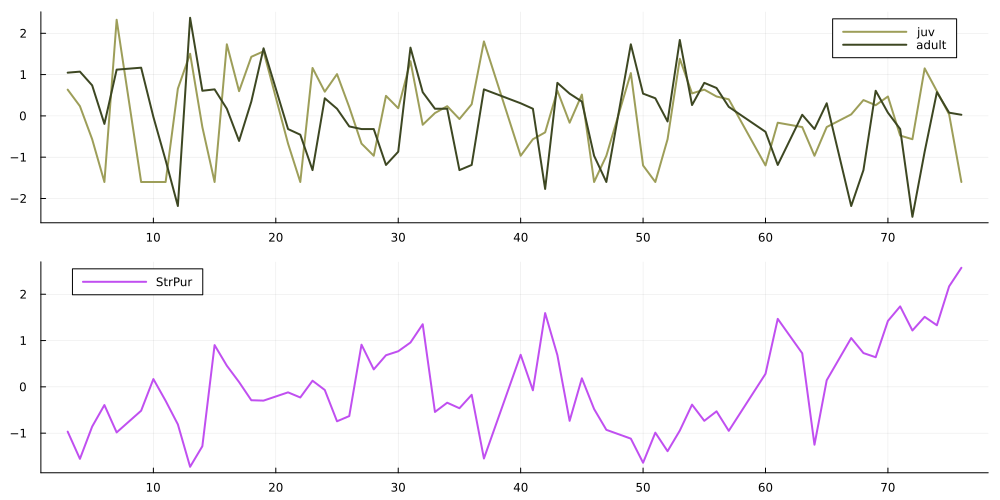

In [14]:
site = 4
dat = CSV.read("../data/processed_time_series.csv", DataFrame)[:,2:end]
dat = sort(dat,:PERIOD)

dat_states = dat[dat.SITE .== site,[:PERIOD,:MacJuv,:MacPyr]]
training = dat_states

X = dat[dat.SITE .== site,[:PERIOD,:StrPur]]



p1 = Plots.plot(training.PERIOD, training.MacJuv, label = "juv", width = 2, color = "#9d9e59" )
Plots.plot!(training.PERIOD, training.MacPyr, label = "adult", width = 2, color = "#3d4722")
# Plots.plot!(testing.PERIOD, testing.MacJuv, label = "juv testing", width = 1.5, linestyle = :dash, color = "#9d9e59")
# Plots.plot!(testing.PERIOD, testing.MacPyr, label = "adult training", width = 1.5,linestyle = :dash, color = "#3d4722")
p2 = Plots.plot(X.PERIOD, X.StrPur, label = "StrPur", width = 2, color = "#c04ff0" )
plot(p1,p2, layout = (2,1), size = (1000,500))

In [15]:
X[1:2,:]

Row,PERIOD,StrPur
,Int64,Float64
1,3,-0.966806
2,4,-1.55477


In [16]:
covars = [1]

NN, NNparameters = UniversalDiffEq.SimpleNeuralNetwork(2+length(covars),2, hidden = 10, seed = 5491)

function dudt(u,X,p,t,covars)
    return NN(vcat(u,X[covars]), p.NN) # index 3 is pycnopodia  ,X[1:2]
end

init_parameters = (NN = NNparameters, )

NODE = UniversalDiffEq.CustomDerivatives(training,X,(u,X,p,t) -> dudt(u,X,p,t,covars),
                                            init_parameters;time_column_name = "PERIOD")

UniversalDiffEq.train!(NODE, loss_function = "spline gradient matching", 
        regularization_weight = 100, optim_options = (maxiter = 500, step_size = 0.025), 
        loss_options = (σ = 0.05, τ = 0.5, T = 2*size(training)[1]))
nothing

132
55255.88 52992.808 50855.269 48836.704 46928.091 45119.071 43399.571 41761.209 40197.038 38701.237 37269.084 35896.853 34581.51 33320.455 32111.445 30952.618 29842.465 28779.706 27763.136 26791.519 25863.518 24977.667 24132.376 23325.975 22556.779 21823.171 21123.644 20456.814 19821.403 19216.208 18640.07 18091.863 17570.481 17074.844 16603.895 16156.6 15731.948 15328.942 14946.589 14583.905 14239.922 13913.711 13604.4 13311.173 13033.27 12769.972 12520.592 12284.468 12060.96 11849.451 11649.346 11460.071 11281.074 11111.822 10951.793 10800.48 10657.391 10522.052 10394.011 10272.836 10158.121 10049.487 9946.575 9849.048 9756.584 9668.882 9585.655 9506.634 9431.57 9360.228 9292.387 9227.837 9166.381 9107.831 9052.013 8998.763 8947.93 8899.377 8852.976 8808.61 8766.171 8725.558 8686.675 8649.433 8613.746 8579.531 8546.71 8515.205 8484.944 8455.856 8427.876 8400.94 8374.991 8349.974 8325.84 8302.54 8280.031 8258.27 8237.219 8216.84 8197.099 8177.963 8159.402 8141.386 8123.889 8106.884

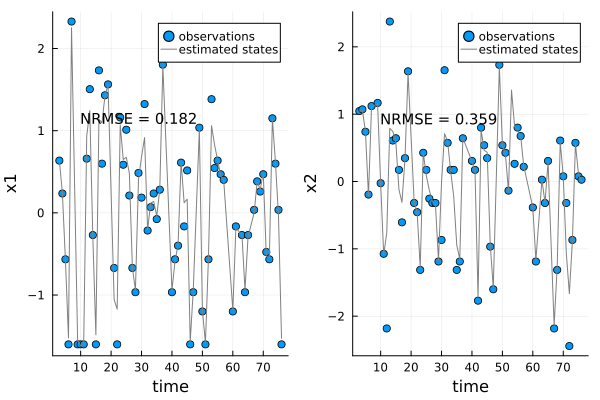

In [17]:
UniversalDiffEq.plot_state_estimates(NODE)

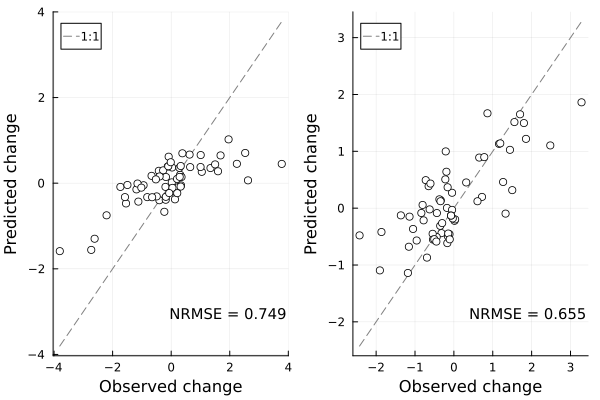

In [18]:
UniversalDiffEq.plot_predictions(NODE)

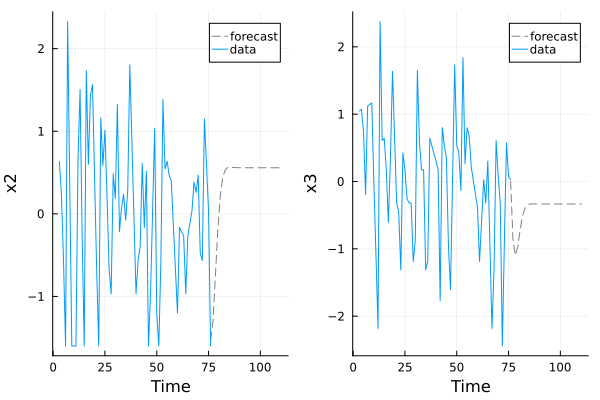

In [19]:
plt,(p1,p2)=UniversalDiffEq.plot_forecast(NODE, 30)
plt

In [ ]:

using ForwardDiff


function transform_states(u,mean,scale)
    y = scale.*exp.(u).+mean
    return y
end


function percap_growth(y,mean,scale)
    u = log.((y.-mean)./scale)
    X = u[3:end]; u = u[1:2]
    dydu = scale[1:2].*exp.(u)
    dudt = rhs(u,X,0.0)
    return dydu.*dudt./y[1:2]
end 


function percap_growth_jacobian(y,mean,scale)
    f = y ->  percap_growth(y,mean,scale)
    return ForwardDiff.jacobian(f, y)
end 


function get_scaling_factors(site)
    scaling_factors  = CSV.read("../data/scaling_factors.csv", DataFrame)[:,2:end]
    scaling_factors = scaling_factors[scaling_factors.SITE.==site,:]
    Xinds = [4,6,1]
    mean = scaling_factors.mean[Xinds]
    scale = scaling_factors.sd[Xinds]
    return scale, mean
end

rhs = UniversalDiffEq.get_right_hand_side(NODE)

scale, means = get_scaling_factors(4)
obs = size(NODE.parameters.uhat)[2]
effects_juv = zeros(obs,3)
effects_adults = zeros(obs,3)
for i in 1:size(NODE.parameters.uhat)[2]
    u = vcat(NODE.parameters.uhat[:,i],Vector(NODE.X[i,2:end]))
    y = transform_states(u,means,scale)
    effects = percap_growth_jacobian(y,means,scale)
    effects_juv[i,:] = effects[1,:]
    effects_adults[i,:] = effects[2,:]
end 


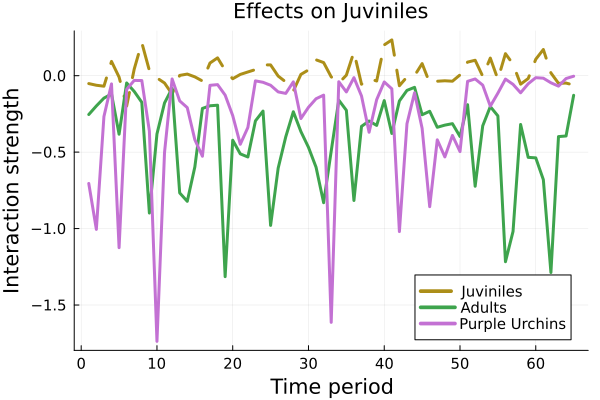

In [22]:
Plots.plot(effects_juv[:,1], width = 3,  label = "Juviniles",c=5,linestyle=:dash)
Plots.plot!(effects_juv[:,2], width = 3,  label = "Adults",c=3)
Plots.plot!(effects_juv[:,3], width = 3, label = "Purple Urchins",c=4)
Plots.plot!(tickfontsize=10, legendfontsize=10, guidefontsize=14,
            xlabel = "Time period",ylabel = "Interaction strength",
            title = "Effects on Juviniles")

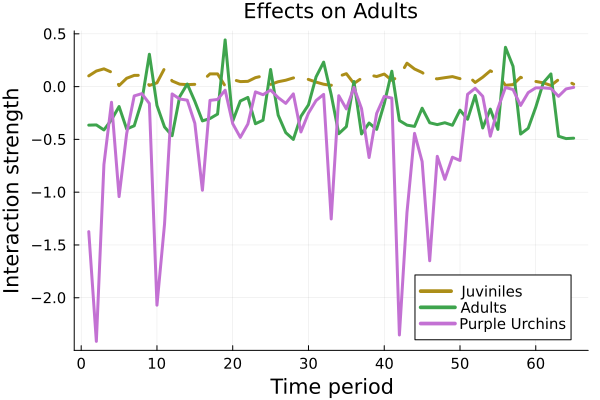

In [23]:
Plots.plot(effects_adults[:,1], width = 3,  label = "Juviniles",c=5,linestyle=:dash)
Plots.plot!(effects_adults[:,2], width = 3,  label = "Adults",c=3)
Plots.plot!(effects_adults[:,3], width = 3, label = "Purple Urchins",c=4)
Plots.plot!(tickfontsize=10, legendfontsize=10, guidefontsize=14,
            xlabel = "Time period",ylabel = "Interaction strength",
            title = "Effects on Adults")